NOTEBOOK 4: Hypothesis Testing
Run AFTER Notebook 3 is complete.
 
Inputs:
    - analytical_dataset.csv
 
Outputs:
    - hypothesis_results.csv     (per-politician Wilcoxon + BH results)
    - significant_politicians.csv (only the statistically significant ones)


Methodology:
    - Paired Wilcoxon Signed-Rank Test per politician
    - Benjamini-Hochberg FDR correction across all politicians
    - Minimum 15 qualifying trades per politician

# CELL 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, DoubleType, IntegerType

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

# CONFIG (OS-independent paths)
INPUT_PATH = Path("data") / "output" / "analytical_dataset.csv"
OUTPUT_ALL = Path("data") / "output" / "hypothesis_results.csv"
OUTPUT_SIG = Path("data") / "output" / "significant_politicians.csv"

# Ensure output directory exists before writing later
OUTPUT_ALL.parent.mkdir(parents=True, exist_ok=True)

MIN_TRADES = 15      # minimum trades to qualify for Wilcoxon test
ALPHA      = 0.05    # significance level (before BH correction)

print("All imports loaded successfully")

All imports loaded successfully


Run this cell below if Cell 2 fails. Or to play safe, just run this cell together.

In [2]:
import os

# 1. Update package lists so it can find the packages
!sudo apt-get update -qq

# 2. Install Java 17 instead of 11
!sudo apt-get install openjdk-17-jdk-headless -qq > /dev/null

# 3. Set the JAVA_HOME environment variable to the Java 17 path
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

# CELL 2 — Start Spark & Load Data

In [3]:
spark = SparkSession.builder \
    .appName("SC2320_Project_Group6_HypothesisTesting") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()
 
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark version: {spark.version}")
 
# PySpark expects a string path, not a pathlib.Path
sdf = spark.read.csv(str(INPUT_PATH), header=True, inferSchema=True)
 
print(f"\nLoaded {sdf.count():,} rows into Spark")
print(f"Columns: {sdf.columns}")
 
sdf.select('politician', 'ticker', 'trade_date',
           'abn_ret_mean', 'ctrl_abn_ret_mean',
           'filed_after_days').show(5, truncate=False)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/22 10:46:29 WARN Utils: Your hostname, codespaces-a752f8, resolves to a loopback address: 127.0.0.1; using 10.0.1.95 instead (on interface eth0)
26/04/22 10:46:29 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/22 10:46:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1



Loaded 22,828 rows into Spark
Columns: ['politician', 'party', 'chamber', 'state', 'company', 'ticker', 'trade_date', 'disclosure_date', 'owner', 'trade_type', 'trade_type_encoded', 'size_bracket', 'size_bracket_ordinal', 'mu_historical', 'sigma_historical', 'n_lookback_obs', 'filed_after_days', 'n_blind_spot_days', 'abn_ret_mean', 'abn_ret_max', 'abn_ret_min', 'car_blind_spot', 'z_car', 'anomaly_flag_L1', 'anomaly_flag_L2', 'n_anomaly_days_L1', 'ctrl_abn_ret_mean', 'ctrl_abn_ret_max', 'car_control', 'z_car_control', 'n_ctrl_days', 'sigma_30', 'stock_return_60d', 'spy_return_60d', 'alpha_60d', 'Y', 'politician_rolling_abn_ret']
+-----------+------+----------+------------+-----------------+----------------+
|politician |ticker|trade_date|abn_ret_mean|ctrl_abn_ret_mean|filed_after_days|
+-----------+------+----------+------------+-----------------+----------------+
|Adam Schiff|AAPL  |2025-09-22|-0.17036    |-0.099995        |9               |
|Angus King |VZ    |2023-12-27|-0.27817    

# CELL 3 — Spark: Filter & Aggregate Per Politician

In [4]:
print("=" * 60)
print("SPARK: Filtering and aggregating per politician")
print("=" * 60)
 
#Keep only rows where both blind spot and control
#         AbnRet values are present (needed for paired test)
sdf_valid = sdf.filter(
    F.col('abn_ret_mean').isNotNull() &
    F.col('ctrl_abn_ret_mean').isNotNull()
)
 
print(f"Rows with valid paired AbnRet values: {sdf_valid.count():,}")
 
#Count trades per politician
trade_counts = sdf_valid.groupBy('politician').agg(
    F.count('*').alias('n_trades'),
    F.first('party').alias('party'),
    F.first('chamber').alias('chamber'),
    F.first('state').alias('state'),
    F.mean('abn_ret_mean').alias('mean_blind_abn_ret'),
    F.mean('ctrl_abn_ret_mean').alias('mean_ctrl_abn_ret'),
    F.expr('percentile(abn_ret_mean, 0.5)').alias('median_blind_abn_ret'),
    F.expr('percentile(ctrl_abn_ret_mean, 0.5)').alias('median_ctrl_abn_ret'),
    F.mean('anomaly_flag_L1').alias('pct_l1_anomaly'),
    F.mean('anomaly_flag_L2').alias('pct_l2_anomaly'),
    F.mean('filed_after_days').alias('avg_filed_after_days'),
)
 
#Filter to politicians with >= MIN_TRADES
qualifying = trade_counts.filter(F.col('n_trades') >= MIN_TRADES)
 
total_politicians = trade_counts.count()
qualifying_count  = qualifying.count()
 
print(f"\nTotal politicians in dataset       : {total_politicians}")
print(f"Politicians with >= {MIN_TRADES} trades       : {qualifying_count}")
print(f"Politicians excluded (< {MIN_TRADES} trades)  : {total_politicians - qualifying_count}")
 
qualifying.orderBy(F.col('n_trades').desc()).show(10, truncate=False)

SPARK: Filtering and aggregating per politician


Rows with valid paired AbnRet values: 22,828

Total politicians in dataset       : 134
Politicians with >= 15 trades       : 71
Politicians excluded (< 15 trades)  : 63


+-----------------+--------+----------+-------+-----+---------------------+----------------------+--------------------+---------------------+--------------------+--------------------+--------------------+
|politician       |n_trades|party     |chamber|state|mean_blind_abn_ret   |mean_ctrl_abn_ret     |median_blind_abn_ret|median_ctrl_abn_ret  |pct_l1_anomaly      |pct_l2_anomaly      |avg_filed_after_days|
+-----------------+--------+----------+-------+-----+---------------------+----------------------+--------------------+---------------------+--------------------+--------------------+--------------------+
|Ro Khanna        |9415    |Democrat  |House  |CA   |9.826008497079428E-4 |-0.0036053917153478538|0.004615            |-0.00149             |0.05023898035050452 |0.0201805629314923  |25.336378120021244  |
|Michael McCaul   |2457    |Republican|House  |TX   |0.02821213186813183  |0.002736602360602365  |0.024867            |0.001297             |0.04884004884004884 |0.0195360195360195

# CELL 4 — Spark: Collect Trade-Level Arrays Per Politician

In [5]:
# For each qualifying politician, collect their blind spot
# and control AbnRet arrays — needed for the Wilcoxon test.
# We use Spark to do the grouping, then convert to pandas.
 
print("Collecting trade arrays per politician via Spark...")
 
# Get list of qualifying politician names
qualifying_names = [row['politician'] for row in qualifying.select('politician').collect()]
 
# Filter original data to qualifying politicians only
sdf_qualifying = sdf_valid.filter(F.col('politician').isin(qualifying_names))
 
# Collect per-politician arrays using Spark collect_list
politician_arrays = sdf_qualifying.groupBy('politician').agg(
    F.collect_list('z_car').alias('blind_spot_values'),
    F.collect_list('z_car_control').alias('control_values'),
)
 
# Convert to pandas for scipy Wilcoxon test
arrays_pdf = politician_arrays.toPandas()
summary_pdf = qualifying.toPandas()
 
print(f"Collected arrays for {len(arrays_pdf)} politicians")
print(f"Sample sizes range: "
      f"{summary_pdf['n_trades'].min()} – {summary_pdf['n_trades'].max()} trades")

Collected arrays for 71 politicians
Sample sizes range: 15 – 9415 trades


# CELL 5 — Scipy: Run Wilcoxon Test Per Politician

In [6]:
# One Wilcoxon test per politician.
 
print("=" * 60)
print("SCIPY: Running Wilcoxon Signed-Rank Test")
print(f"Testing {len(arrays_pdf)} politicians...")
print("=" * 60)
 
wilcoxon_results = []
 
for _, row in arrays_pdf.iterrows():
    politician   = row['politician']
    blind_vals   = np.array(row['blind_spot_values'], dtype=float)
    control_vals = np.array(row['control_values'],    dtype=float)
 
    # Compute pairwise differences
    differences = blind_vals - control_vals
 
    # Remove zero differences (Wilcoxon requirement)
    # Zeros carry no rank information
    nonzero_mask = differences != 0
    n_nonzero    = nonzero_mask.sum()
    differences  = differences[nonzero_mask]
 
    # Need at least 6 non-zero differences for valid test
    if n_nonzero < 6:
        wilcoxon_results.append({
            'politician':    politician,
            'n_pairs':       len(blind_vals),
            'n_nonzero':     n_nonzero,
            'statistic':     np.nan,
            'p_value':       np.nan,
            'drop_reason':   f'only {n_nonzero} non-zero differences'
        })
        continue
 
    try:
        # alternative='greater' tests if blind spot > control
        # This is a one-sided test matching our H1 direction
        stat, pval = wilcoxon(differences,
                              alternative='greater',
                              zero_method='wilcox')
 
        wilcoxon_results.append({
            'politician':  politician,
            'n_pairs':     len(blind_vals),
            'n_nonzero':   n_nonzero,
            'statistic':   round(stat, 4),
            'p_value':     round(pval, 6),
            'drop_reason': None
        })
 
    except Exception as e:
        wilcoxon_results.append({
            'politician':  politician,
            'n_pairs':     len(blind_vals),
            'n_nonzero':   n_nonzero,
            'statistic':   np.nan,
            'p_value':     np.nan,
            'drop_reason': str(e)
        })
 
wilcoxon_df = pd.DataFrame(wilcoxon_results)
 
# Separate valid results from failed
valid_results  = wilcoxon_df[wilcoxon_df['p_value'].notna()].copy()
failed_results = wilcoxon_df[wilcoxon_df['p_value'].isna()].copy()
 
print(f"\nWilcoxon tests run successfully : {len(valid_results)}")
print(f"Tests failed / insufficient data: {len(failed_results)}")
if len(failed_results) > 0:
    print(f"\nFailed politicians:")
    print(failed_results[['politician', 'n_pairs', 'drop_reason']].to_string(index=False))

SCIPY: Running Wilcoxon Signed-Rank Test
Testing 71 politicians...

Wilcoxon tests run successfully : 71
Tests failed / insufficient data: 0


# CELL 6 — Benjamini-Hochberg FDR Correction

In [7]:
print("=" * 60)
print("BENJAMINI-HOCHBERG FDR CORRECTION")
print("=" * 60)
 
pvalues = valid_results['p_value'].values
 
# multipletests returns:
# reject      — boolean array: True = reject H0 (significant)
# pvals_corrected — BH-adjusted p-values
# alphacSidak, alphacBonf — other thresholds (not used here)
reject, pvals_corrected, _, _ = multipletests(
    pvalues,
    alpha=ALPHA,
    method='fdr_bh'
)
 
valid_results['p_value_bh']   = pvals_corrected.round(6)
valid_results['significant']  = reject
 
n_significant = reject.sum()
print(f"\nAlpha level                     : {ALPHA}")
print(f"Politicians tested              : {len(valid_results)}")
print(f"Significant BEFORE BH correction: {(pvalues < ALPHA).sum()}")
print(f"Significant AFTER  BH correction: {n_significant}")
print(f"False positives avoided         : "
      f"{(pvalues < ALPHA).sum() - n_significant}")
 
print(f"\nInterpretation:")
print(f"  Without BH correction, we expected ~"
      f"{int(len(valid_results) * ALPHA)} false positives by chance alone.")
print(f"  After correction, {n_significant} politicians are genuinely significant.")

BENJAMINI-HOCHBERG FDR CORRECTION

Alpha level                     : 0.05
Politicians tested              : 71
Significant BEFORE BH correction: 11
Significant AFTER  BH correction: 5
False positives avoided         : 6

Interpretation:
  Without BH correction, we expected ~3 false positives by chance alone.
  After correction, 5 politicians are genuinely significant.


# CELL 7 — Merge All Results Into Final Table

In [8]:
# Merge Wilcoxon results with summary stats from Spark
final_results = summary_pdf.merge(
    valid_results[['politician', 'n_pairs', 'n_nonzero',
                   'statistic', 'p_value', 'p_value_bh', 'significant']],
    on='politician',
    how='left'
)
 
# Compute difference column (key metric for report)
final_results['abn_ret_difference'] = (
    final_results['mean_blind_abn_ret'] - final_results['mean_ctrl_abn_ret']
).round(4)
 
# Sort by significant first, then by BH p-value
final_results = final_results.sort_values(
    ['significant', 'p_value_bh'],
    ascending=[False, True]
).reset_index(drop=True)
 
# Rank column
final_results.insert(0, 'rank', range(1, len(final_results) + 1))
 
print("=" * 60)
print("FINAL HYPOTHESIS TESTING RESULTS")
print("=" * 60)
print(f"\nTop 20 politicians by significance:\n")
 
display_cols = ['rank', 'politician', 'party', 'chamber',
                'n_trades', 'median_blind_abn_ret', 'median_ctrl_abn_ret',
                'abn_ret_difference', 'p_value', 'p_value_bh', 'significant']
 
print(final_results[display_cols].head(20).to_string(index=False))

FINAL HYPOTHESIS TESTING RESULTS

Top 20 politicians by significance:

 rank             politician      party chamber  n_trades  median_blind_abn_ret  median_ctrl_abn_ret  abn_ret_difference  p_value  p_value_bh  significant
    1         Michael McCaul Republican   House      2457              0.024867             0.001297              0.0255 0.000001    0.000071         True
    2      Daniel S. Goldman   Democrat   House       447              0.006007            -0.023029              0.0496 0.000039    0.001384         True
    3          Pete Ricketts Republican  Senate        23              0.137974            -0.052939              0.2290 0.000091    0.002154         True
    4 Marjorie Taylor Greene Republican   House       177              0.115807             0.000009              0.0994 0.002050    0.036388         True
    5              Ro Khanna   Democrat   House      9415              0.004615            -0.001490              0.0046 0.002739    0.038894         True

# CELL 8 — Chart 1: Significant Politicians Bar Char


Significant politicians: 5


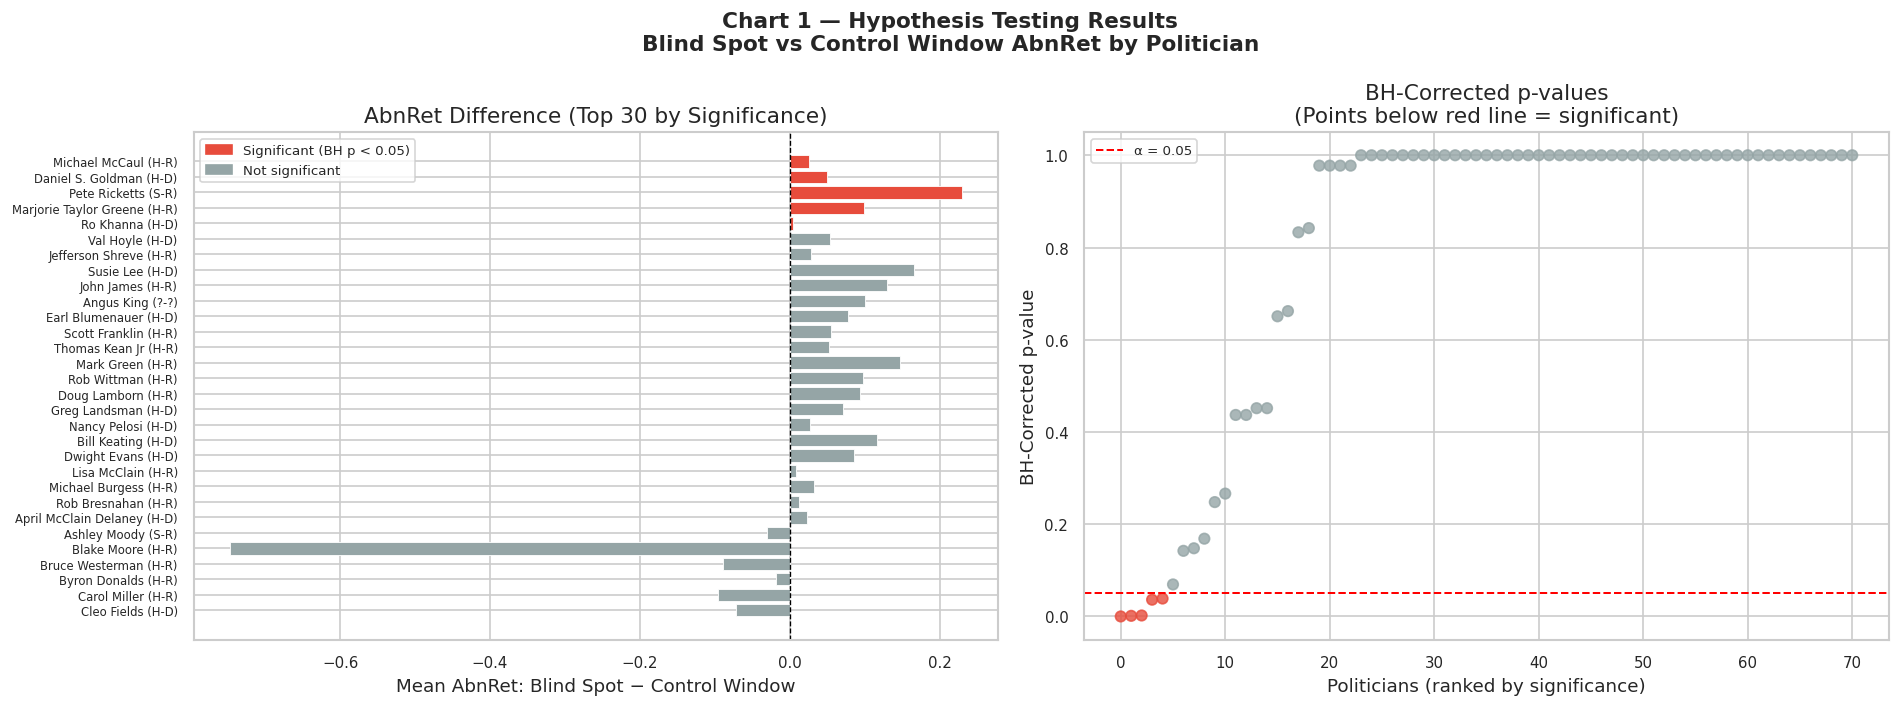

Chart 1 saved to: data/output/chart1_hypothesis_results.png


In [9]:
sig_politicians = final_results[final_results['significant'] == True].copy()
nonsig          = final_results[final_results['significant'] == False].copy()
 
print(f"\nSignificant politicians: {len(sig_politicians)}")
if len(sig_politicians) == 0:
    print("No significant politicians found after BH correction.")
    print("This is a valid finding — it suggests the STOCK Act is working.")
    print("Proceed to charts showing the full distribution instead.")
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Chart 1 — Hypothesis Testing Results\n"
             "Blind Spot vs Control Window AbnRet by Politician",
             fontsize=13, fontweight='bold')
 
# Left: AbnRet difference for top 30 politicians
ax = axes[0]
plot_data = final_results.head(30).copy()

plot_data['politician'] = plot_data['politician'].fillna('Unknown')
plot_data['chamber'] = plot_data['chamber'].fillna('?')
plot_data['party'] = plot_data['party'].fillna('?')

colors = ['#E74C3C' if sig else '#95A5A6'
          for sig in plot_data['significant']]
bars = ax.barh(range(len(plot_data)),
               plot_data['abn_ret_difference'],
               color=colors, edgecolor='white', linewidth=0.5)

ax.set_yticks(range(len(plot_data)))

# FIX: Added str() casting as an extra safeguard
ax.set_yticklabels(
    [f"{str(row['politician'])[:25]} ({str(row['chamber'])[0]}-{str(row['party'])[0]})" 
     for _, row in plot_data.iterrows()],
    fontsize=7
)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel("Mean AbnRet: Blind Spot − Control Window")
ax.set_title("AbnRet Difference (Top 30 by Significance)")
ax.invert_yaxis()

red_patch  = mpatches.Patch(color='#E74C3C', label=f'Significant (BH p < {ALPHA})')
grey_patch = mpatches.Patch(color='#95A5A6', label='Not significant')
ax.legend(handles=[red_patch, grey_patch], fontsize=8)
 
# Right: BH-corrected p-values
ax2 = axes[1]
ax2.scatter(range(len(final_results)),
            final_results['p_value_bh'],
            c=['#E74C3C' if s else '#95A5A6'
               for s in final_results['significant']],
            s=40, alpha=0.8)
ax2.axhline(ALPHA, color='red', linestyle='--', linewidth=1.2,
            label=f'α = {ALPHA}')
ax2.set_xlabel("Politicians (ranked by significance)")
ax2.set_ylabel("BH-Corrected p-value")
ax2.set_title("BH-Corrected p-values\n(Points below red line = significant)")
ax2.legend(fontsize=8)
 
plt.tight_layout()
out_path = os.path.join('data', 'output', 'chart1_hypothesis_results.png')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Chart 1 saved to: {out_path}")

# CELL 9 — Chart 2: Blind Spot vs Control Box Plot

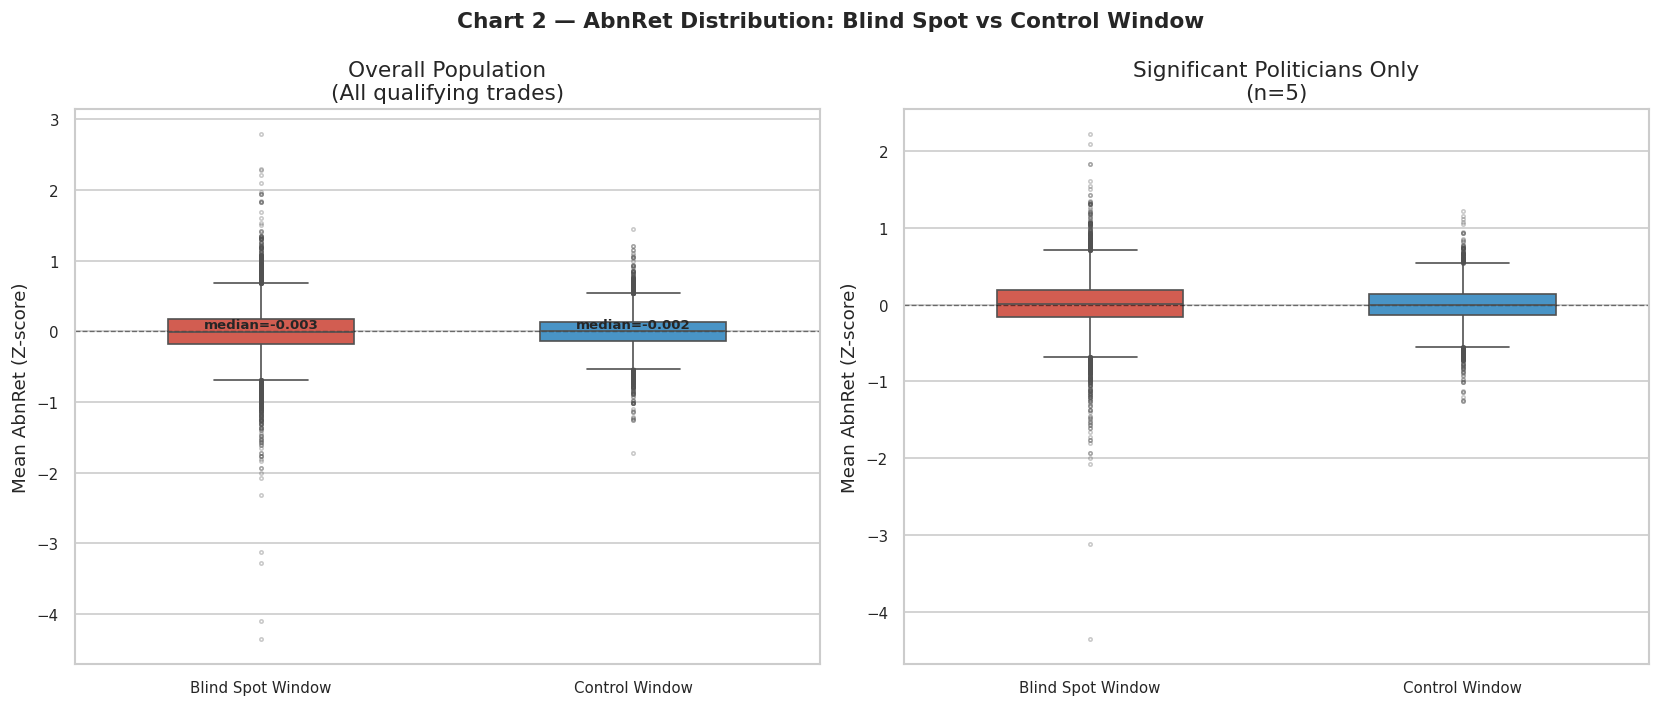

Chart 2 saved to: data/output/chart2_blindspot_vs_control.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Chart 2 — AbnRet Distribution: Blind Spot vs Control Window",
             fontsize=13, fontweight='bold')
 
# Prepare long-format data for seaborn
analytical_pdf = pd.read_csv(INPUT_PATH)
analytical_pdf = analytical_pdf.dropna(
    subset=['abn_ret_mean', 'ctrl_abn_ret_mean']
)
 
plot_long = pd.melt(
    analytical_pdf[['politician', 'abn_ret_mean', 'ctrl_abn_ret_mean']],
    id_vars=['politician'],
    value_vars=['abn_ret_mean', 'ctrl_abn_ret_mean'],
    var_name='window_type',
    value_name='abn_ret'
)
plot_long['window_type'] = plot_long['window_type'].map({
    'abn_ret_mean':      'Blind Spot Window',
    'ctrl_abn_ret_mean': 'Control Window'
})
 
# Left: overall distribution comparison
ax = axes[0]
sns.boxplot(data=plot_long, x='window_type', y='abn_ret',
            palette={'Blind Spot Window': '#E74C3C',
                     'Control Window':    '#3498DB'},
            ax=ax, width=0.5,
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel("")
ax.set_ylabel("Mean AbnRet (Z-score)")
ax.set_title("Overall Population\n(All qualifying trades)")
 
# Annotate medians
for i, window in enumerate(['Blind Spot Window', 'Control Window']):
    med = plot_long[plot_long['window_type'] == window]['abn_ret'].median()
    ax.text(i, med + 0.05, f"median={med:.3f}",
            ha='center', fontsize=8, fontweight='bold')
 
# Right: significant politicians only
ax2 = axes[1]
if len(sig_politicians) > 0:
    sig_names = sig_politicians['politician'].tolist()
    sig_data  = plot_long[plot_long['politician'].isin(sig_names)]
    sns.boxplot(data=sig_data, x='window_type', y='abn_ret',
                palette={'Blind Spot Window': '#E74C3C',
                         'Control Window':    '#3498DB'},
                ax=ax2, width=0.5,
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax2.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax2.set_xlabel("")
    ax2.set_ylabel("Mean AbnRet (Z-score)")
    ax2.set_title(f"Significant Politicians Only\n(n={len(sig_politicians)})")
else:
    ax2.text(0.5, 0.5, "No significant politicians\nfound after BH correction",
             ha='center', va='center', transform=ax2.transAxes, fontsize=11)
    ax2.set_title("Significant Politicians Only")

 
plt.tight_layout()
out_path = os.path.join('data', 'output', 'chart2_blindspot_vs_control.png')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Chart 2 saved to: {out_path}")
 

# CELL 10 — Chart 3: Party & Chamber Breakdown

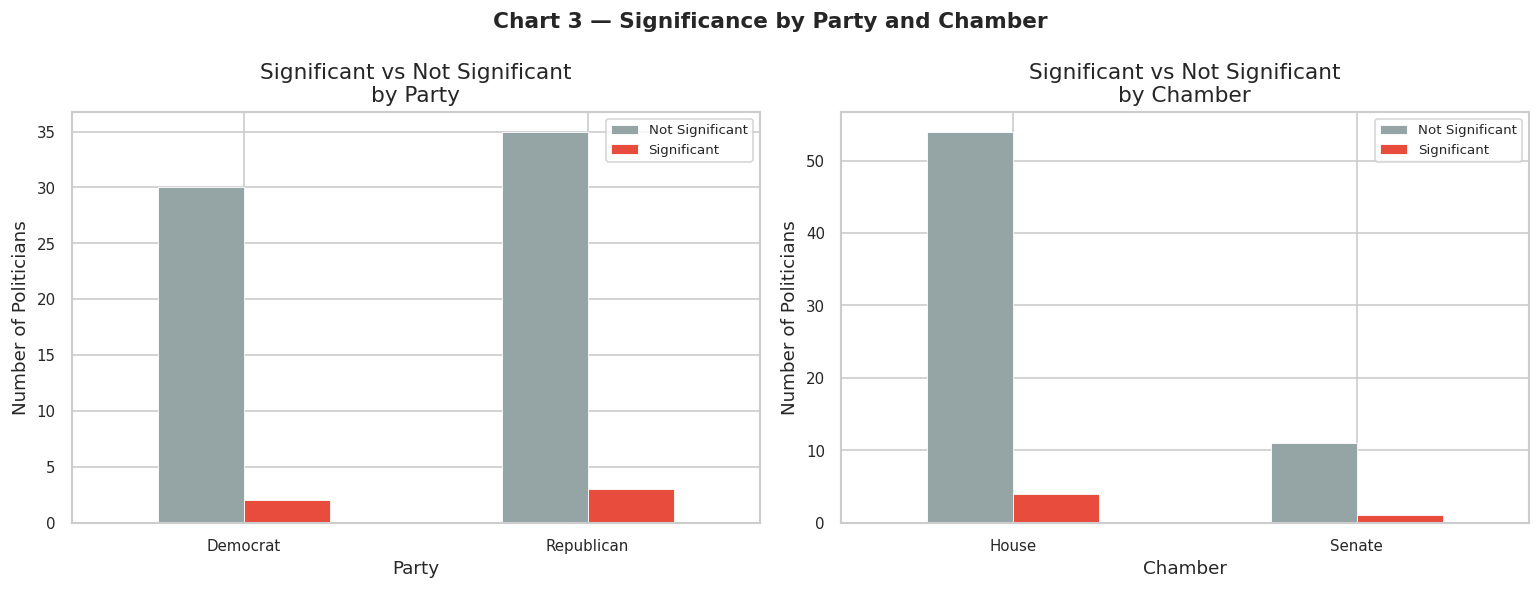

Chart 3 saved to: data/output/chart3_significance_breakdown.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Chart 3 — Significance by Party and Chamber",
             fontsize=13, fontweight='bold')
 
# Left: by party
ax = axes[0]
party_sig = final_results.groupby(['party', 'significant']).size().unstack(fill_value=0)
party_sig.plot(kind='bar', ax=ax,
               color=['#95A5A6', '#E74C3C'],
               edgecolor='white', linewidth=0.5)
ax.set_xlabel("Party")
ax.set_ylabel("Number of Politicians")
ax.set_title("Significant vs Not Significant\nby Party")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['Not Significant', 'Significant'], fontsize=8)
 
# Right: by chamber
ax2 = axes[1]
chamber_sig = final_results.groupby(
    ['chamber', 'significant']).size().unstack(fill_value=0)
chamber_sig.plot(kind='bar', ax=ax2,
                 color=['#95A5A6', '#E74C3C'],
                 edgecolor='white', linewidth=0.5)
ax2.set_xlabel("Chamber")
ax2.set_ylabel("Number of Politicians")
ax2.set_title("Significant vs Not Significant\nby Chamber")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(['Not Significant', 'Significant'], fontsize=8)

 
plt.tight_layout()
out_path = os.path.join('data', 'output', 'chart3_significance_breakdown.png')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Chart 3 saved to: {out_path}")

# CELL 11 — Save Outputs via Spark

In [12]:
# Convert final results back to Spark for saving
final_spark = spark.createDataFrame(
    final_results[display_cols + ['mean_blind_abn_ret', 'mean_ctrl_abn_ret',
                                   'abn_ret_difference', 'pct_l1_anomaly',
                                   'pct_l2_anomaly', 'avg_filed_after_days']]
    .fillna('')
)
 
# Save full results
final_results.to_csv(OUTPUT_ALL, index=False)
 
# Save significant politicians only
if len(sig_politicians) > 0:
    sig_output = final_results[final_results['significant'] == True]
    sig_output.to_csv(OUTPUT_SIG, index=False)
    print(f"Saved {OUTPUT_SIG} — {len(sig_output)} significant politicians")
 
print(f"Saved {OUTPUT_ALL} — {len(final_results)} total politicians tested")

Saved data/output/significant_politicians.csv — 5 significant politicians
Saved data/output/hypothesis_results.csv — 71 total politicians tested


# CELL 12 — Final Summary for Report

In [13]:
print("=" * 60)
print("NOTEBOOK 4 SUMMARY FOR REPORT")
print("=" * 60)
print(f"\nH0: blind spot AbnRet = control window AbnRet")
print(f"H1: blind spot AbnRet > control window AbnRet (one-sided)\n")
print(f"Politicians tested (>= {MIN_TRADES} trades)  : {len(valid_results)}")
print(f"Significance level (alpha)         : {ALPHA}")
print(f"Correction method                  : Benjamini-Hochberg FDR\n")
print(f"Significant BEFORE correction      : {(pvalues < ALPHA).sum()}")
print(f"Significant AFTER  correction      : {n_significant}")
 
if n_significant > 0:
    print(f"\nTop 5 significant politicians:")
    print(
        final_results[final_results['significant'] == True]
        [['politician', 'party', 'chamber', 'n_trades',
          'median_blind_abn_ret', 'median_ctrl_abn_ret',
          'p_value', 'p_value_bh']]
        .head(5)
        .to_string(index=False)
    )
    print(f"\nConclusion: {n_significant} politicians show statistically significant")
    print(f"abnormal returns during their disclosure blind spot window,")
    print(f"consistent with systematic information asymmetry.")
else:
    print(f"\nConclusion: No politicians show statistically significant")
    print(f"abnormal returns after BH correction at alpha = {ALPHA}.")
    print(f"This is consistent with the STOCK Act being an effective deterrent,")
    print(f"or with the signal being too small to detect at this sample size.")
 
print(f"\nNotebook 4 complete. Proceed to Notebook 5.")
 
spark.stop()

NOTEBOOK 4 SUMMARY FOR REPORT

H0: blind spot AbnRet = control window AbnRet
H1: blind spot AbnRet > control window AbnRet (one-sided)

Politicians tested (>= 15 trades)  : 71
Significance level (alpha)         : 0.05
Correction method                  : Benjamini-Hochberg FDR

Significant BEFORE correction      : 11
Significant AFTER  correction      : 5

Top 5 significant politicians:
            politician      party chamber  n_trades  median_blind_abn_ret  median_ctrl_abn_ret  p_value  p_value_bh
        Michael McCaul Republican   House      2457              0.024867             0.001297 0.000001    0.000071
     Daniel S. Goldman   Democrat   House       447              0.006007            -0.023029 0.000039    0.001384
         Pete Ricketts Republican  Senate        23              0.137974            -0.052939 0.000091    0.002154
Marjorie Taylor Greene Republican   House       177              0.115807             0.000009 0.002050    0.036388
             Ro Khanna   Democ